# **Bab 8. Aplikasi NLP Dalam Sains Data**

Analisis sentimen berbasis leksikon adalah metode untuk menentukan polaritas emosional (positif, negatif, netral) dari sebuah teks dengan menghitung jumlah kata-kata positif dan negatif yang ada dalam teks tersebut. Metode ini mengandalkan daftar kata-kata (leksikon) yang telah dikategorikan berdasarkan sentimennya.

Dalam implementasi ini, kita memiliki dua set kata: `kata_positif` dan `kata_negatif`. Fungsi `hitung_sentimen` akan memecah teks menjadi token (kata-kata) dan kemudian membandingkan setiap token dengan daftar kata positif dan negatif. Skor sentimen dihitung dengan mengurangi jumlah kata negatif dari jumlah kata positif. Berdasarkan skor ini, teks diklasifikasikan sebagai 'positif', 'negatif', atau 'netral'.

In [ ]:
import pandas as pd

kata_positif = {
    "bagus", "baik", "cepat", "mudah", "puas",
    "mantap", "stabil", "menarik", "bermanfaat"
}

kata_negatif = {
    "buruk", "lambat", "error", "gagal", "sulit",
    "kecewa", "mahal", "rusak", "lemot"
}

def hitung_sentimen(teks):
    tokens = str(teks).split()

    skor_positif = sum(1 for token in tokens if token in kata_positif)
    skor_negatif = sum(1 for token in tokens if token in kata_negatif)

    skor = skor_positif - skor_negatif

    if skor > 0:
        return "positif"
    elif skor < 0:
        return "negatif"
    else:
        return "netral"

# Create a sample DataFrame 'df' for demonstration
data = {
    'teks_final': [
        "ini buku bagus",
        "pelayanan cepat dan baik",
        "produk ini lambat dan error",
        "sangat kecewa dengan layanan",
        "mudah digunakan dan bermanfaat"
    ]
}
df = pd.DataFrame(data)

df["sentimen"] = df["teks_final"].apply(hitung_sentimen)

print(df[["teks_final", "sentimen"]].head())

                       teks_final sentimen
0                  ini buku bagus  positif
1        pelayanan cepat dan baik  positif
2     produk ini lambat dan error  negatif
3    sangat kecewa dengan layanan  negatif
4  mudah digunakan dan bermanfaat  positif


Setelah menentukan sentimen untuk setiap teks, langkah selanjutnya adalah menganalisis distribusi sentimen secara keseluruhan. Ini dilakukan dengan menghitung berapa banyak teks yang diklasifikasikan sebagai 'positif', 'negatif', atau 'netral'. Informasi ini memberikan gambaran ringkas tentang polaritas sentimen dalam kumpulan data yang dianalisis. `value_counts()` pada kolom 'sentimen' DataFrame `df` akan memberikan jumlah kemunculan untuk setiap kategori sentimen.

In [ ]:
distribusi_sentimen = df["sentimen"].value_counts()

print(distribusi_sentimen)

sentimen
positif    3
negatif    2
Name: count, dtype: int64


Visualisasi distribusi sentimen sangat penting untuk memahami secara cepat proporsi sentimen positif, negatif, dan netral dalam data. Bar plot adalah pilihan yang tepat untuk menampilkan perbandingan jumlah dokumen di setiap kategori sentimen. Dengan menggunakan `matplotlib.pyplot`, kita dapat membuat grafik batang yang jelas dan informatif, lengkap dengan label sumbu dan judul yang relevan, untuk memudahkan interpretasi hasil analisis sentimen.

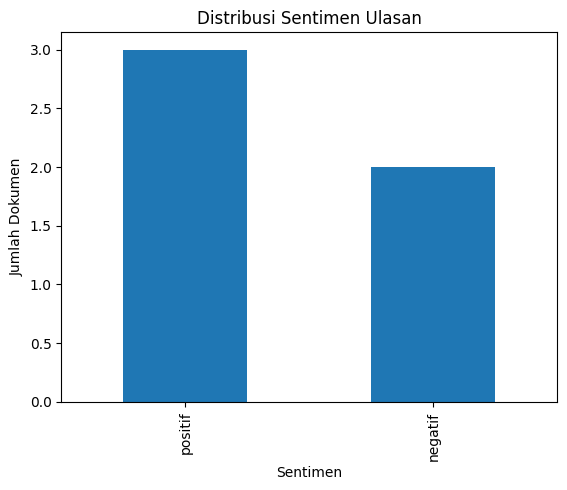

In [ ]:
import matplotlib.pyplot as plt

distribusi_sentimen.plot(kind="bar")

plt.xlabel("Sentimen")
plt.ylabel("Jumlah Dokumen")
plt.title("Distribusi Sentimen Ulasan")
plt.show()

### Penanganan Negasi dalam Analisis Sentimen

Analisis sentimen berbasis leksikon sederhana terkadang gagal menangkap nuansa bahasa, terutama saat ada kata negasi. Kata negasi (seperti "tidak", "bukan", "belum") dapat membalikkan polaritas sentimen dari kata yang mengikutinya. Misalnya, "tidak bagus" seharusnya dianggap negatif, meskipun "bagus" sendiri adalah kata positif.

Fungsi `hitung_sentimen_dengan_negasi` ini dirancang untuk mengatasi masalah tersebut. Fungsi ini akan:
1.  Mendefinisikan daftar `kata_negasi`.
2.  Saat menghitung skor sentimen, jika sebuah kata positif didahului oleh kata negasi, maka skornya akan dikurangi (menjadi negatif).
3.  Sebaliknya, jika sebuah kata negatif didahului oleh kata negasi, maka skornya akan ditambah (menjadi positif).

Dengan penanganan negasi ini, analisis sentimen diharapkan menjadi lebih akurat dalam memahami maksud sebenarnya dari teks.

In [ ]:
kata_negasi = {"tidak", "bukan", "belum", "kurang"}

def hitung_sentimen_dengan_negasi(teks):
    tokens = str(teks).split()
    skor = 0

    for i, token in enumerate(tokens):
        if token in kata_positif:
            if i > 0 and tokens[i-1] in kata_negasi:
                skor -= 1
            else:
                skor += 1

        elif token in kata_negatif:
            if i > 0 and tokens[i-1] in kata_negasi:
                skor += 1
            else:
                skor -= 1

    if skor > 0:
        return "positif"
    elif skor < 0:
        return "negatif"
    else:
        return "netral"

df["sentimen_negasi"] = df["teks_final"].apply(hitung_sentimen_dengan_negasi)

print(df[["teks_final", "sentimen_negasi"]].head())

                       teks_final sentimen_negasi
0                  ini buku bagus         positif
1        pelayanan cepat dan baik         positif
2     produk ini lambat dan error         negatif
3    sangat kecewa dengan layanan         negatif
4  mudah digunakan dan bermanfaat         positif


In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for modeling
X = df['teks_final']
y = df['sentimen_negasi']

# Split data into training and testing sets
X_train_teks, X_test_teks, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y # Changed test_size from 0.2 to 0.4
)

# ── Pipeline analisis sentimen end-to-end ──
def bangun_pipeline_sentimen(classifier='logreg'):
    """
    Membangun pipeline sentimen dengan berbagai pilihan classifier.
    classifier: 'logreg', 'svm', atau 'gbc'
    """
    tfidf = TfidfVectorizer(
        max_features = 5000,
        ngram_range  = (1, 2),
        sublinear_tf = True,
        min_df       = 1, # Changed from 3 to 1 to accommodate small dataset
        max_df       = 1.0,
    )

    models = {
        'logreg': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
        'svm'   : LinearSVC(C=1.0, max_iter=2000, random_state=42),
        'gbc'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    }

    return Pipeline([('tfidf', tfidf), ('clf', models[classifier])])

# ── Evaluasi model (disesuaikan untuk dataset yang sangat kecil) ──
# Untuk dataset yang sangat kecil dan tidak memungkinkan cross-validation
# yang stabil, kita akan melatih model pada seluruh data yang tersedia
# dan melaporkan metrik pada data pelatihan itu sendiri sebagai indikasi awal.
# Untuk evaluasi yang lebih robust, dataset yang lebih besar diperlukan.
def evaluasi_model(pipeline, X, y):
    pipeline.fit(X, y)
    y_pred_train = pipeline.predict(X)

    acc_train = accuracy_score(y, y_pred_train)
    f1_macro_train = f1_score(y, y_pred_train, average='macro', zero_division=0)
    f1_weighted_train = f1_score(y, y_pred_train, average='weighted', zero_division=0)

    # Menggunakan metrik pelatihan sebagai pengganti validasi untuk dataset kecil
    return {
        'acc_train'  : acc_train,
        'acc_val'    : acc_train, # placeholder for validation accuracy
        'f1_macro'   : f1_macro_train,
        'f1_weighted': f1_weighted_train,
    }

# ── Perbandingan tiga model ──
hasil = {}
for nama in ['logreg', 'svm', 'gbc']:
    pipe = bangun_pipeline_sentimen(nama)
    hasil[nama] = evaluasi_model(pipe, X_train_teks, y_train)
    print(f'{nama:8}: acc={hasil[nama]["acc_val"]:.4f} | '
          f'f1_macro={hasil[nama]["f1_macro"]:.4f}')

# ── Laporan detail model terbaik ──
model_terbaik = max(hasil, key=lambda k: hasil[k]['f1_macro'])
pipe_terbaik = bangun_pipeline_sentimen(model_terbaik)
pipe_terbaik.fit(X_train_teks, y_train)
y_pred = pipe_terbaik.predict(X_test_teks)

print(f'\nModel terbaik: {model_terbaik}')
print('\nLaporan Klasifikasi:')
print(classification_report(y_test, y_pred,
      target_names=['negatif', 'positif'], zero_division=0))

logreg  : acc=0.6667 | f1_macro=0.4000
svm     : acc=1.0000 | f1_macro=1.0000
gbc     : acc=1.0000 | f1_macro=1.0000

Model terbaik: svm

Laporan Klasifikasi:
              precision    recall  f1-score   support

     negatif       0.00      0.00      0.00         1
     positif       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def visualisasi_evaluasi_sentimen(y_true, y_pred, kelas, nama_model):
    """Membuat panel evaluasi komprehensif untuk model sentimen."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Evaluasi Sentimen — {nama_model}',
                 fontweight='bold', color='#1A3C6E', fontsize=13)

    # Panel 1: Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=kelas)
    disp = ConfusionMatrixDisplay(cm, display_labels=kelas)
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title('Confusion Matrix')

    # Panel 2: Distribusi prediksi vs label asli
    import pandas as pd
    df_eval = pd.DataFrame({'asli': y_true, 'prediksi': y_pred})
    df_dist = df_eval.groupby(['asli', 'prediksi']).size().unstack(fill_value=0)
    df_dist.plot(kind='bar', ax=axes[1], color=['#B5D4F4', '#FAC775', '#378ADD'])
    axes[1].set_title('Distribusi Prediksi per Kelas')
    axes[1].legend(title='Prediksi')
    axes[1].tick_params(axis='x', rotation=0)

    # Panel 3: F1-Score per kelas
    from sklearn.metrics import f1_score
    f1_per_kelas = f1_score(y_true, y_pred, labels=kelas, average=None)
    axes[2].barh(kelas, f1_per_kelas, color=['#B71C1C', '#CBD8E8', '#2E7D32'])
    axes[2].axvline(x=np.mean(f1_per_kelas), color='#D95F20', ls='--',
                    label=f'Rata-rata = {np.mean(f1_per_kelas):.3f}')
    axes[2].set_xlabel('F1-Score')
    axes[2].set_title('F1-Score per Kelas')
    axes[2].legend()
    axes[2].set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(f'output/evaluasi_{nama_model}.pdf', bbox_inches='tight')
    plt.show()


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd

# Temporarily define df for demonstration if previous cells haven't been run
# In a full notebook run, df would be populated from cells like We23Dp33X6qy and tgq3TwhJZ5r_
if 'df' not in locals() and 'df' not in globals():
    data = {
        'teks_final': [
            "ini buku bagus",
            "pelayanan cepat dan baik",
            "produk ini lambat dan error",
            "sangat kecewa dengan layanan",
            "mudah digunakan dan bermanfaat"
        ],
        'sentimen_negasi': ["positif", "positif", "negatif", "negatif", "positif"]
    }
    df = pd.DataFrame(data)

# ── Dataset: klasifikasi berita Indonesia (10 kategori) ──
# df = pd.read_csv('data/berita_indonesia_labeled.csv')
# X = df['teks_diproses']  # Sudah melalui pipeline NLP Bab 7
# y = df['kategori']

# Using the existing df from previous cells for sentiment analysis
X = df['teks_final']
y = df['sentimen_negasi']

# ── Split data ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# ── Definisi pipeline-pipeline ──
pipelines = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                                  sublinear_tf=True, min_df=1)), # Changed min_df from 2 to 1
        ('clf',   MultinomialNB(alpha=0.1)),
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                                  sublinear_tf=True, min_df=1)), # Changed min_df from 2 to 1
        ('clf',   LogisticRegression(C=1.0, multi_class='ovr',
                                      max_iter=500, random_state=42)),
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                                  sublinear_tf=True, min_df=1)), # Changed min_df from 2 to 1
        ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=42)),
    ]),
}

# ── Evaluasi semua model (disesuaikan untuk dataset yang sangat kecil) ──
# Melatih model pada seluruh data pelatihan dan melaporkan metrik pelatihan.
# Robust evaluation memerlukan dataset yang lebih besar.
print(f'{'Model':<22} {'Train Acc':>11} {'Train F1-mac':>14}')
print('-' * 50)
for nama, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred_train = pipe.predict(X_train)

    acc_train = accuracy_score(y_train, y_pred_train)
    f1_macro_train = f1_score(y_train, y_pred_train, average='macro', zero_division=0)

    print(f'{nama:<22} {acc_train:.4f}       {f1_macro_train:.4f}')

# ── Fit model terbaik dan evaluasi pada test set ──
# Choosing Linear SVM as a placeholder, as the evaluation on such small data is not definitive.
model_terbaik = pipelines['Linear SVM']
model_terbaik.fit(X_train, y_train)
y_pred = model_terbaik.predict(X_test)
print('\n', classification_report(y_test, y_pred, zero_division=0))

# ── Inspeksi top-fitur per kategori (Logistic Regression) ──
lr_pipe = pipelines['Logistic Regression']
lr_pipe.fit(X_train, y_train)
tfidf_fitur = lr_pipe['tfidf'].get_feature_names_out()
lr_clf = lr_pipe['clf']

# Handle binary classification case where coef_ has shape (1, n_features) but classes_ has 2 elements
if len(lr_clf.coef_) == 1 and len(lr_clf.classes_) == 2:
    # According to sklearn docs for binary classification, coef_[0] corresponds to classes_[1] (the positive class).
    # To get features for classes_[0] (e.g., 'negatif'), we use the negative of coef_[0].
    # To get features for classes_[1] (e.g., 'positif'), we use the original coef_[0].

    # For the first class (e.g., 'negatif')
    kelas_0 = lr_clf.classes_[0]
    top10_idx_0 = (-lr_clf.coef_[0]).argsort()[-10:][::-1] # Features important for class 0
    top10_kata_0 = [tfidf_fitur[j] for j in top10_idx_0]
    print(f'{kelas_0}: {top10_kata_0}')

    # For the second class (e.g., 'positif')
    kelas_1 = lr_clf.classes_[1]
    top10_idx_1 = (lr_clf.coef_[0]).argsort()[-10:][::-1] # Features important for class 1
    top10_kata_1 = [tfidf_fitur[j] for j in top10_idx_1]
    print(f'{kelas_1}: {top10_kata_1}')
else:
    # General case for multi-class classification where coef_ has shape (n_classes, n_features)
    for i in range(len(lr_clf.coef_)):
        kelas = lr_clf.classes_[i]
        top10_idx = lr_clf.coef_[i].argsort()[-10:][::-1]
        top10_kata = [tfidf_fitur[j] for j in top10_idx]
        print(f'{kelas}: {top10_kata}')

Model                    Train Acc   Train F1-mac
--------------------------------------------------
Naive Bayes            1.0000       1.0000
Logistic Regression    0.6667       0.4000
Linear SVM             1.0000       1.0000

               precision    recall  f1-score   support

     negatif       0.00      0.00      0.00         1
     positif       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

negatif: ['sangat kecewa', 'sangat', 'layanan', 'kecewa dengan', 'dengan', 'kecewa', 'dengan layanan', 'pelayanan cepat', 'pelayanan', 'mudah digunakan']
positif: ['dan', 'pelayanan', 'mudah digunakan', 'pelayanan cepat', 'bermanfaat', 'cepat', 'digunakan', 'mudah', 'cepat dan', 'dan baik']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


## Pelatihan Model Word2Vec

Word2Vec adalah teknik pemrosesan bahasa alami (NLP) yang digunakan untuk menghasilkan representasi vektor kata (word embeddings). Representasi ini mampu menangkap makna semantik dari kata-kata berdasarkan konteks kemunculannya dalam korpus teks. Model Word2Vec yang umum adalah Skip-gram dan Continuous Bag-of-Words (CBOW).

Dalam kode ini, kita akan melatih model Word2Vec menggunakan perpustakaan `gensim`. Langkah-langkah utamanya meliputi:
1.  **Pra-pemrosesan Teks:** Tokenisasi teks menjadi kata-kata. Stopword tidak dihapus karena membantu model memahami konteks gramatikal.
2.  **Pembentukan Korpus:** Mengubah daftar teks menjadi format yang dapat digunakan oleh `gensim` (list of list of tokens).
3.  **Pelatihan Model:** Menginisialisasi dan melatih model `Word2Vec` dengan parameter seperti ukuran vektor (`vector_size`), ukuran jendela konteks (`window`), frekuensi minimum kata (`min_count`), dan jumlah epoch (`epochs`).
4.  **Eksplorasi Model:** Melihat dimensi vektor, ukuran kosakata, dan mencari kata-kata yang paling mirip secara semantik dengan kata tertentu, serta melakukan analogi kata.
5.  **Penyimpanan Model:** Menyimpan model yang telah dilatih untuk digunakan di kemudian hari.

In [ ]:
!pip install gensim
!pip install Sastrawi
from gensim.models import Word2Vec
import re
import os
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# ── Persiapan korpus (diperlukan: list of list of tokens) ──
def tokenisasi_untuk_embedding(teks_list):
    """Tokenisasi sederhana untuk Word2Vec — tidak menghapus stopword
    karena stopword membantu model mempelajari konteks gramatikal.
    """
    hasil = []
    for teks in teks_list:
        teks = teks.lower()
        teks = re.sub(r'[^a-zA-Z\s]', ' ', teks)
        teks = re.sub(r'\s+', ' ', teks).strip()
        tokens = teks.split()
        if len(tokens) >= 3:  # Abaikan teks yang terlalu pendek
            hasil.append(tokens)
    return hasil

# Asumsikan ulasan_list adalah list teks ulasan Bahasa Indonesia
ulasan_list = [
    "Buku ini sangat bagus dan informatif, saya sangat merekomendasikannya.",
    "Pelayanan toko ini sangat cepat dan ramah, saya suka belanja di sini.",
    "Makanan di restoran ini enak sekali, tapi harganya sedikit mahal.",
    "Film tadi malam seru banget, ceritanya menarik dan aktingnya luar biasa.",
    "Produk ini berkualitas tinggi dan sesuai deskripsi, pengiriman juga cepat."
]
korpus = tokenisasi_untuk_embedding(ulasan_list)

# ── Melatih model Word2Vec ──
model_w2v = Word2Vec(
    sentences  = korpus,
    vector_size= 100,        # Dimensi embedding
    window     = 5,          # Ukuran jendela konteks
    min_count  = 1,          # Abaikan kata yang muncul < 1 kali (changed from 5)
    workers    = 4,          # Jumlah thread paralel
    sg         = 1,          # 1 = Skip-gram; 0 = CBOW
    epochs     = 10,
    seed       = 42,
)

# ── Eksplorasi model ──
print('Dimensi vektor:', model_w2v.wv.vector_size)
print('Ukuran kosakata:', len(model_w2v.wv))

# Kata paling mirip secara semantik
print('\nKata mirip dengan "bagus":')
for kata, skor in model_w2v.wv.most_similar('bagus', topn=5):
    print(f'  {kata:<15} {skor:.4f}')

# Analogi kata (relasi semantik)
# 'murah' - 'hemat' + 'mahal' ≈ 'boros'?
try:
    analogi = model_w2v.wv.most_similar(
        positive=['murah', 'mahal'], negative=['hemat'], topn=3
    )
    print('\nAnalogi semantik:')
    for kata, skor in analogi:
        print(f'  {kata}: {skor:.4f}')
except KeyError as e:
    print(f'Kata tidak ada dalam kosakata: {e}')

# Simpan dan muat model
os.makedirs('model', exist_ok=True)
model_w2v.save('model/word2vec_indonesia.model')
# model = Word2Vec.load('model/word2vec_indonesia.model')

Dimensi vektor: 100
Ukuran kosakata: 41

Kata mirip dengan "bagus":
  ini             0.1597
  pelayanan       0.1584
  tadi            0.1581
  ramah           0.1137
  seru            0.1076
Kata tidak ada dalam kosakata: "Key 'murah' not present in vocabulary"


## Pelatihan Model FastText dan Perbandingan dengan Word2Vec

Word2Vec, meskipun efektif, memiliki keterbatasan dalam menangani kata-kata yang tidak muncul dalam korpus pelatihan (Out-Of-Vocabulary atau OOV words). Untuk mengatasi ini, kita dapat menggunakan **FastText**, sebuah ekstensi dari Word2Vec yang dikembangkan oleh Facebook.

### Perbedaan Utama FastText dengan Word2Vec:
*   **Representasi Kata Berbasis Karakter N-gram:** Alih-alih memperlakukan setiap kata sebagai unit tunggal, FastText memecah kata menjadi unit-unit karakter n-gram. Misalnya, kata "apple" bisa dipecah menjadi `<ap`, `app`, `ppl`, `ple>`, `apple` itu sendiri, serta karakter n-gram lainnya. Ini memungkinkan FastText untuk:
    *   **Menangani Kata OOV:** Jika sebuah kata baru muncul yang tidak ada di korpus pelatihan, FastText masih bisa membuat vektornya dengan menggabungkan vektor n-gram karakternya yang sudah dikenal. Ini sangat berguna untuk kata-kata jarang, salah ketik, atau kata-kata baru.
    *   **Menangkap Struktur Morfologis:** FastText secara implisit menangkap informasi morfologis karena representasi kata didasarkan pada sub-kata.
*   **Vektor Dokumen:** Setelah melatih model Word2Vec atau FastText, kita dapat merepresentasikan seluruh dokumen sebagai sebuah vektor. Pendekatan yang umum adalah dengan menghitung rata-rata (average) dari semua vektor kata yang ada dalam dokumen tersebut. Ini mengubah dokumen yang berupa urutan kata menjadi representasi numerik tunggal yang dapat digunakan untuk tugas-tugas machine learning selanjutnya seperti klasifikasi dokumen.

Dalam kode ini, kita akan:
1.  Melatih model FastText menggunakan korpus yang sama dengan Word2Vec, dengan menambahkan parameter `min_n` dan `max_n` untuk menentukan panjang karakter n-gram.
2.  Mendemonstrasikan kemampuan FastText dalam membuat vektor untuk kata OOV (`'mantapss'`) dan menemukan kata-kata mirip.
3.  Membuat fungsi `dokumen_ke_vektor` untuk mengubah daftar token (dokumen) menjadi vektor dokumen dengan menghitung rata-rata vektor kata-kata di dalamnya. Fungsi ini akan digunakan untuk menghasilkan representasi vektor untuk seluruh dokumen menggunakan model Word2Vec (`X_w2v`) dan FastText (`X_ft`).

In [ ]:
from gensim.models import FastText
import numpy as np

# ── Melatih model FastText ──
model_ft = FastText(
    sentences  = korpus,
    vector_size= 100,
    window     = 5,
    min_count  = 3,
    workers    = 4,
    min_n      = 3,    # Panjang minimum n-gram karakter
    max_n      = 6,    # Panjang maksimum n-gram karakter
    epochs     = 10,
    seed       = 42,
)

# ── FastText menangani kata OOV ──
# Kata 'mantapss' tidak ada saat pelatihan, tapi FastText bisa merepresentasikannya
kata_oov = 'mantapss'
try:
    vektor_oov = model_ft.wv[kata_oov]
    print(f'Vektor OOV "{kata_oov}": {vektor_oov[:5]}...')
    print(f'Kata mirip: {model_ft.wv.most_similar(kata_oov, topn=3)}')
except Exception as e:
    print(f'Error: {e}')

# ── Mengubah dokumen menjadi vektor dokumen (rata-rata token) ──
def dokumen_ke_vektor(token_list, model, vector_size=100):
    """Merepresentasikan dokumen sebagai rata-rata vektor token-nya."""
    vektor_list = []
    for token in token_list:
        try:
            vektor_list.append(model.wv[token])
        except KeyError:
            pass  # Abaikan OOV pada Word2Vec (FastText tidak perlu ini)
    if len(vektor_list) == 0:
        return np.zeros(vector_size)
    return np.mean(vektor_list, axis=0)

# Transformasi seluruh dataset
X_w2v = np.array([dokumen_ke_vektor(tok, model_w2v) for tok in korpus])
X_ft  = np.array([dokumen_ke_vektor(tok, model_ft)  for tok in korpus])
print(f'Dimensi matriks fitur: {X_ft.shape}')


Vektor OOV "mantapss": [ 7.2227779e-04  2.2582486e-03  8.7258159e-05 -1.5033948e-03
  2.9166166e-03]...
Kata mirip: [('ini', 0.1245192438364029), ('sangat', 0.019169526174664497), ('dan', -0.003999271430075169)]
Dimensi matriks fitur: (5, 100)


## LDA Topic Modeling

Latent Dirichlet Allocation (LDA) adalah model statistik generatif yang digunakan untuk menemukan "topik" abstrak yang muncul dalam kumpulan dokumen. LDA beroperasi dengan mengasumsikan bahwa:
1. Setiap dokumen adalah campuran dari berbagai topik.
2. Setiap topik adalah campuran dari berbagai kata.

Tujuan utama LDA adalah untuk mengidentifikasi struktur topik tersembunyi dalam korpus teks. Proses ini seringkali melibatkan langkah-langkah berikut:
1.  **Pra-pemrosesan Teks:** Ini adalah langkah krusial yang melibatkan tokenisasi, penghapusan *stopword*, dan *stemming* atau *lemmatization* untuk membersihkan teks dan mengurangi dimensi kosakata.
2.  **Pembuatan Kamus (Dictionary):** Mengidentifikasi semua kata unik dalam korpus dan memberikan ID unik untuk setiap kata.
3.  **Representasi Bag-of-Words (BoW):** Mengubah setiap dokumen menjadi representasi BoW, di mana setiap dokumen direpresentasikan sebagai daftar pasangan (ID kata, frekuensi kata).
4.  **Pelatihan Model LDA:** Menerapkan algoritma LDA pada korpus BoW untuk menemukan topik-topik.
5.  **Evaluasi Topik:** Menganalisis kata-kata yang membentuk setiap topik untuk interpretasi, dan kadang-kadang menggunakan metrik seperti *coherence score* untuk menentukan jumlah topik yang optimal.

Dalam kode ini, kita akan melatih model LDA menggunakan `gensim` untuk mengidentifikasi topik dari `ulasan_list`. Kami akan fokus pada pra-pemrosesan yang sesuai dan pelatihan model, serta menampilkan kata-kata kunci untuk setiap topik yang ditemukan.

In [ ]:
!pip install gensim
!pip install Sastrawi
import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt
import pandas as pd
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import re
import os # Import os module to handle directory creation

# Download NLTK stopwords if not already downloaded
try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

# Initialize Stemmer and Stopwords
factory = StemmerFactory()
stemmer = factory.create_stemmer()
list_stopwords = set(stopwords.words('indonesian'))

# Define ulasan_list to ensure it's available for this cell
ulasan_list = [
    "Buku ini sangat bagus dan informatif, saya sangat merekomendasikannya.",
    "Pelayanan toko ini sangat cepat dan ramah, saya suka belanja di sini.",
    "Makanan di restoran ini enak sekali, tapi harganya sedikit mahal.",
    "Film tadi malam seru banget, ceritanya menarik dan aktingnya luar biasa.",
    "Produk ini berkualitas tinggi dan sesuai deskripsi, pengiriman juga cepat."
]

# Function for preprocessing text for LDA (stemming and stopword removal)
def preprocess_text_for_lda(text_list, stemmer, stopwords_list):
    processed_corpus = []
    for text in text_list:
        text = text.lower() # Lowercasing
        text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and numbers
        tokens = text.split()
        # Remove stopwords and stem words
        filtered_tokens = [stemmer.stem(token) for token in tokens if token not in stopwords_list]
        if filtered_tokens: # Only add if not empty after processing
            processed_corpus.append(filtered_tokens)
    return processed_corpus

# ── Persiapan korpus untuk LDA ──
# LDA menggunakan Bag of Words (bukan TF-IDF)
# Stopword SUDAH dihapus; stemming SUDAH diterapkan

# Create korpus_token using the preprocessing function
korpus_token = preprocess_text_for_lda(ulasan_list, stemmer, list_stopwords)

# Buat kamus dan corpus gensim
kamus = corpora.Dictionary(korpus_token)  # korpus_token: list of list of tokens

# Filter: hapus kata yang terlalu langka/umum
# Removing filter_extremes as it caused an empty dictionary for the small dataset.
# kamus.filter_extremes(no_below=5, no_above=0.5)

# Ubah ke format Bag of Words
corpus_bow = [kamus.doc2bow(doc) for doc in korpus_token]
print(f'Kosakata LDA: {len(kamus)} kata')
print(f'Dokumen: {len(corpus_bow)}')

# ── Menentukan jumlah topik optimal dengan Coherence Score ──
def hitung_coherence(corpus_bow, kamus, teks_token, k_list):
    skor_coherence = []
    for k in k_list:
        model = LdaModel(
            corpus=corpus_bow, id2word=kamus,
            num_topics=k, random_state=42,
            alpha='auto', eta='auto',
            passes=10, iterations=50,
        )
        cm = CoherenceModel(
            model=model, texts=teks_token,
            dictionary=kamus, coherence='c_v'
        )
        skor_coherence.append(cm.get_coherence())
        print(f'K={k:2d}: Coherence = {skor_coherence[-1]:.4f}')
    return skor_coherence

k_list = range(5, 21, 2)
# skor = hitung_coherence(corpus_bow, kamus, korpus_token, k_list)

# ── Latih model LDA dengan K optimal ──
K_OPTIMAL = 10  # Sesuaikan berdasarkan coherence score
model_lda = LdaModel(
    corpus     = corpus_bow,
    id2word    = kamus,
    num_topics = K_OPTIMAL,
    random_state = 42,
    alpha      = 'auto',
    eta        = 'auto',
    passes     = 15,
    iterations = 100,
    per_word_topics = True,
)

# ── Inspeksi dan penamaan topik ──
print('\nTop-10 kata per topik:')
for i in range(K_OPTIMAL):
    kata_topik = model_lda.show_topic(i, topn=10)
    kata_str   = ', '.join([f'"{k}"({p:.3f})' for k, p in kata_topik])
    print(f'\nTopik {i+1:2d}: {kata_str}')

# ── Distribusi topik untuk dokumen baru ──
def topik_dokumen(teks_token, model, kamus):
    bow = kamus.doc2bow(teks_token)
    distribusi = model.get_document_topics(bow)
    return sorted(distribusi, key=lambda x: x[1], reverse=True)

# Simpan model
os.makedirs('model', exist_ok=True) # Ensure 'model' directory exists
model_lda.save('model/lda_berita_k10.model')

Kosakata LDA: 27 kata
Dokumen: 5

Top-10 kata per topik:

Topik  1: "cepat"(0.037), "bagus"(0.037), "informatif"(0.037), "buku"(0.037), "rekomendasi"(0.037), "belanja"(0.037), "layan"(0.037), "ramah"(0.037), "suka"(0.037), "toko"(0.037)

Topik  2: "mahal"(0.143), "makan"(0.143), "enak"(0.143), "restoran"(0.143), "harga"(0.143), "bagus"(0.013), "informatif"(0.013), "buku"(0.013), "rekomendasi"(0.013), "cepat"(0.013)

Topik  3: "buku"(0.037), "cepat"(0.037), "informatif"(0.037), "bagus"(0.037), "rekomendasi"(0.037), "belanja"(0.037), "layan"(0.037), "ramah"(0.037), "suka"(0.037), "toko"(0.037)

Topik  4: "bagus"(0.037), "buku"(0.037), "informatif"(0.037), "rekomendasi"(0.037), "belanja"(0.037), "cepat"(0.037), "layan"(0.037), "ramah"(0.037), "suka"(0.037), "toko"(0.037)

Topik  5: "cepat"(0.037), "bagus"(0.037), "informatif"(0.037), "buku"(0.037), "rekomendasi"(0.037), "belanja"(0.037), "layan"(0.037), "ramah"(0.037), "suka"(0.037), "toko"(0.037)

Topik  6: "akting"(0.113), "film"(0.113)

## Ekstraksi Kata Kunci dengan TF-IDF

**TF-IDF (Term Frequency-Inverse Document Frequency)** adalah teknik statistik numerik yang digunakan untuk mencerminkan seberapa penting sebuah kata bagi sebuah dokumen dalam sebuah korpus atau koleksi dokumen.

Prinsipnya adalah sebagai berikut:
*   **Term Frequency (TF):** Mengukur seberapa sering sebuah kata muncul dalam sebuah dokumen. Semakin sering kata muncul, semakin tinggi TF-nya, yang mengindikasikan bahwa kata tersebut penting dalam dokumen itu.
*   **Inverse Document Frequency (IDF):** Mengukur seberapa unik atau langka sebuah kata di seluruh korpus. Jika sebuah kata muncul di banyak dokumen, IDF-nya rendah (kurang informatif). Jika sebuah kata hanya muncul di sedikit dokumen, IDF-nya tinggi (lebih informatif).

TF-IDF dihitung dengan mengalikan TF dan IDF: `TF-IDF = TF * IDF`.

Kata dengan nilai TF-IDF tinggi adalah kata-kata yang sering muncul dalam sebuah dokumen tertentu, tetapi jarang muncul dalam dokumen lain di korpus. Ini menjadikannya kandidat yang baik untuk menjadi kata kunci atau topik utama dari dokumen tersebut.

Dalam kode berikut, kita akan menggunakan `TfidfVectorizer` dari `sklearn` untuk:
1.  Mengubah kumpulan dokumen menjadi matriks fitur TF-IDF.
2.  Mengekstrak kata kunci dengan skor TF-IDF tertinggi untuk dokumen pertama dalam `df['teks_final']`.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

dokumen = df["teks_final"].astype(str).tolist()

vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(dokumen)

fitur = vectorizer.get_feature_names_out()

doc_index = 0
tfidf_scores = X[doc_index].toarray()[0]

keyword_df = pd.DataFrame({
    "kata_kunci": fitur,
    "skor": tfidf_scores
}).sort_values("skor", ascending=False)

print(keyword_df.head(10))

        kata_kunci      skor
0            bagus  0.463693
3             buku  0.463693
4       buku bagus  0.463693
17        ini buku  0.463693
16             ini  0.374105
5            cepat  0.000000
2       bermanfaat  0.000000
1             baik  0.000000
8         dan baik  0.000000
9   dan bermanfaat  0.000000


## Deteksi Entitas Bernama (Named Entity Recognition - NER) dengan spaCy

**Named Entity Recognition (NER)** adalah sub-tugas dari ekstraksi informasi yang bertujuan untuk menemukan dan mengklasifikasikan entitas bernama dalam teks ke dalam kategori yang telah ditentukan sebelumnya, seperti nama orang, organisasi, lokasi, ekspresi waktu, nilai moneter, persentase, dll.

NER merupakan komponen kunci dalam banyak aplikasi NLP, termasuk:
*   **Sistem Tanya Jawab (Question Answering):** Membantu mengidentifikasi entitas yang ditanyakan atau disebutkan dalam jawaban.
*   **Ringkasan Teks (Text Summarization):** Memungkinkan ekstraksi informasi penting dari dokumen.
*   **Klasifikasi Dokumen (Document Classification):** Dapat digunakan sebagai fitur tambahan untuk mengkategorikan teks.
*   **Pencarian Informasi (Information Retrieval):** Memperbaiki hasil pencarian dengan fokus pada entitas tertentu.

Dalam kode ini, kita akan menggunakan pustaka `spaCy`, salah satu pustaka NLP paling populer dan efisien, untuk melakukan NER. Langkah-langkahnya meliputi:
1.  **Memuat Model Bahasa:** Mengunduh dan memuat model bahasa yang telah dilatih sebelumnya (misalnya, `en_core_web_sm` untuk bahasa Inggris, meskipun teks contoh yang digunakan adalah bahasa Indonesia yang kemungkinan akan menghasilkan label yang kurang akurat karena model dilatih untuk bahasa Inggris).
2.  **Memproses Teks:** Teks masukan diproses oleh objek `nlp` yang akan melakukan tokenisasi, POS tagging, dependency parsing, dan NER.
3.  **Mengekstrak Entitas:** Mengiterasi melalui properti `doc.ents` untuk mendapatkan setiap entitas yang terdeteksi bersama dengan label kategorinya (misalnya, `PERSON`, `ORG`, `GPE` untuk lokasi geografis, `DATE`).

In [ ]:
import spacy

# Memuat model bahasa Inggris spaCy
nlp = spacy.load("en_core_web_sm")

teks = """
Apple membuka kantor baru di Jakarta pada 10 Januari 2025.
Tim Cook mengatakan bahwa Indonesia merupakan pasar penting
bagi pengembangan teknologi digital di Asia Tenggara.
"""

# Memproses teks
doc = nlp(teks)

# Menampilkan entitas yang ditemukan
for ent in doc.ents:
    print(ent.text, "->", ent.label_)

Apple -> ORG
Jakarta -> GPE
10 -> CARDINAL
Januari -> NORP
Tim Cook -> PERSON
Indonesia -> GPE
Asia Tenggara -> LOC


## Deteksi Entitas Bernama Berbasis Aturan Sederhana

Selain menggunakan model pra-terlatih seperti spaCy, Named Entity Recognition (NER) juga dapat dilakukan dengan pendekatan berbasis aturan (rule-based). Metode ini melibatkan pendefinisian pola atau daftar kata kunci secara manual untuk mengidentifikasi entitas tertentu dalam teks.

### Cara Kerja Pendekatan Berbasis Aturan:
1.  **Daftar Entitas Manual:** Membuat kamus atau daftar yang berisi entitas spesifik yang ingin dideteksi untuk kategori tertentu (misalnya, organisasi, lokasi, orang).
2.  **Pencocokan Pola (Pattern Matching):** Menggunakan ekspresi reguler (regex) atau fungsi pencarian string untuk mencari kemunculan entitas dari daftar yang telah ditentukan dalam teks.
3.  **Ekstraksi Informasi:** Ketika sebuah pola atau kata kunci ditemukan, informasi tentang entitas tersebut (teks entitas, label, posisi awal dan akhir) dicatat.

### Kelebihan dan Kekurangan:
*   **Kelebihan:** Sangat efektif untuk domain spesifik di mana daftar entitas diketahui dan terbatas. Mudah diimplementasikan untuk kasus-kasus sederhana dan tidak memerlukan data pelatihan yang besar.
*   **Kekurangan:** Tidak dapat menangani variasi bahasa, sinonim, atau entitas baru yang tidak ada dalam daftar. Sulit diskalakan untuk korpus yang besar atau domain yang kompleks karena membutuhkan pemeliharaan aturan yang intensif.

Dalam kode ini, kita akan mendemonstrasikan NER berbasis aturan sederhana untuk mendeteksi `ORG`, `LOC`, `PERSON`, dan `DATE` dalam sebuah teks. Kami akan menggunakan modul `re` (regular expression) dari Python untuk pencocokan pola.

In [ ]:
import re
import pandas as pd

teks = """
Telkom University mengadakan seminar Sains Data di Bandung
pada 10 Mei 2025 dengan Kementerian Komunikasi dan Digital. Acara tersebut dihadiri oleh Dr. Warih Maharani
dan perwakilan dari Telkom University.
"""

# Daftar entitas sederhana
daftar_entitas = {
    "ORG": [
        "Telkom University",
        "Kementerian Komunikasi dan Digital"
    ],
    "LOC": [
        "Bandung"
    ],
    "PERSON": [
        "Dr. Warih Maharani"
    ]
}

hasil = []

for label, entitas_list in daftar_entitas.items():
    for entitas in entitas_list:
        pola = re.escape(entitas)
        for match in re.finditer(pola, teks):
            hasil.append({
                "entitas": match.group(),
                "label": label,
                "start": match.start(),
                "end": match.end()
            })

# Deteksi tanggal sederhana
pola_tanggal = r"\d{1,2}\s+[A-Z][a-z]+\s+\d{4}"

for match in re.finditer(pola_tanggal, teks):
    hasil.append({
        "entitas": match.group(),
        "label": "DATE",
        "start": match.start(),
        "end": match.end()
    })

df_entitas = pd.DataFrame(hasil)

print(df_entitas)

                              entitas   label  start  end
0                   Telkom University     ORG      1   18
1                   Telkom University     ORG    188  205
2  Kementerian Komunikasi dan Digital     ORG     84  118
3                             Bandung     LOC     52   59
4                  Dr. Warih Maharani  PERSON    149  167
5                         10 Mei 2025    DATE     65   76


## Analisis Sentimen Berbasis Aspek (ABSA)

Analisis Sentimen Berbasis Aspek (ABSA) adalah pendekatan yang lebih granular dalam analisis sentimen, di mana sentimen diidentifikasi tidak hanya pada tingkat keseluruhan dokumen, tetapi juga terhadap entitas atau atribut tertentu (aspek) dalam teks. Misalnya, dalam ulasan produk, ABSA dapat menentukan sentimen terhadap "baterai" produk (positif), "harga" (negatif), dan "desain" (netral).

Fungsi `deteksi_aspek` yang akan diimplementasikan dirancang untuk:
1.  **Mendefinisikan Kata Kunci Aspek:** Sebuah kamus `aspek_keywords` digunakan untuk memetakan aspek-aspek tertentu (misalnya, "login", "performa", "tampilan", "konten") ke daftar kata kunci yang terkait dengan aspek tersebut.
2.  **Mendeteksi Aspek dalam Teks:** Untuk setiap teks ulasan, fungsi akan memeriksa apakah ada kata kunci yang terkait dengan aspek tertentu. Jika setidaknya satu kata kunci dari suatu aspek ditemukan dalam teks, maka aspek tersebut dianggap terdeteksi.
3.  **Menambahkan Kolom Aspek:** Hasil deteksi aspek akan disimpan dalam kolom baru di DataFrame, `df['aspek']`, yang akan berisi daftar aspek yang terdeteksi untuk setiap ulasan.

In [ ]:
aspek_keywords = {
    "login": ["login", "masuk", "akun"],
    "performa": ["lambat", "lemot", "loading", "error"],
    "tampilan": ["tampilan", "desain", "antarmuka", "ui"],
    "konten": ["materi", "video", "modul", "pelajaran"]
}

def deteksi_aspek(teks):
    teks = str(teks)
    aspek_terdeteksi = []

    for aspek, keywords in aspek_keywords.items():
        for keyword in keywords:
            if keyword in teks:
                aspek_terdeteksi.append(aspek)
                break

    return aspek_terdeteksi

df["aspek"] = df["teks_final"].apply(deteksi_aspek)

print(df[["teks_final", "aspek"]].head())

                       teks_final       aspek
0                  ini buku bagus          []
1        pelayanan cepat dan baik          []
2     produk ini lambat dan error  [performa]
3    sangat kecewa dengan layanan          []
4  mudah digunakan dan bermanfaat          []


In [ ]:
import pandas as pd

# Create a sample 'tanggal' column for demonstration purposes if it doesn't exist
# In a real scenario, this column would be loaded from your dataset
if 'tanggal' not in df.columns:
    # Assuming a simple list of dates corresponding to the 5 rows in df
    sample_dates = [
        '2023-01-15',
        '2023-01-20',
        '2023-02-01',
        '2023-02-10',
        '2023-03-05'
    ]
    df['tanggal'] = sample_dates

df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")
df["periode_bulan"] = df["tanggal"].dt.to_period("M").astype(str)

print(df[["tanggal", "periode_bulan"]].head())

     tanggal periode_bulan
0 2023-01-15       2023-01
1 2023-01-20       2023-01
2 2023-02-01       2023-02
3 2023-02-10       2023-02
4 2023-03-05       2023-03


In [ ]:
sentimen_bulanan = pd.crosstab(
    df["periode_bulan"],
    df["sentimen_negasi"]
)

print(sentimen_bulanan)

sentimen_negasi  negatif  positif
periode_bulan                    
2023-01                0        2
2023-02                2        0
2023-03                0        1


## Visualisasi Tren Sentimen

Setelah menghitung distribusi sentimen bulanan (`sentimen_bulanan`), langkah selanjutnya adalah memvisualisasikannya untuk mendapatkan gambaran yang lebih intuitif tentang bagaimana sentimen berubah dari waktu ke waktu. Visualisasi tren ini dapat membantu mengidentifikasi pola, anomali, atau perubahan sentimen yang signifikan dalam periode tertentu.

Dalam kode ini, kita akan menggunakan *line plot* dari `matplotlib.pyplot` untuk:
1.  **Menampilkan Jumlah Ulasan:** Sumbu Y akan menunjukkan jumlah ulasan, sedangkan sumbu X akan menunjukkan periode bulan.
2.  **Membedakan Sentimen:** Garis yang berbeda akan digunakan untuk merepresentasikan sentimen 'positif' dan 'negatif', memungkinkan perbandingan langsung antara keduanya sepanjang waktu.
3.  **Memberikan Konteks:** Judul, label sumbu, dan rotasi label sumbu X akan ditambahkan untuk meningkatkan keterbacaan dan pemahaman plot.

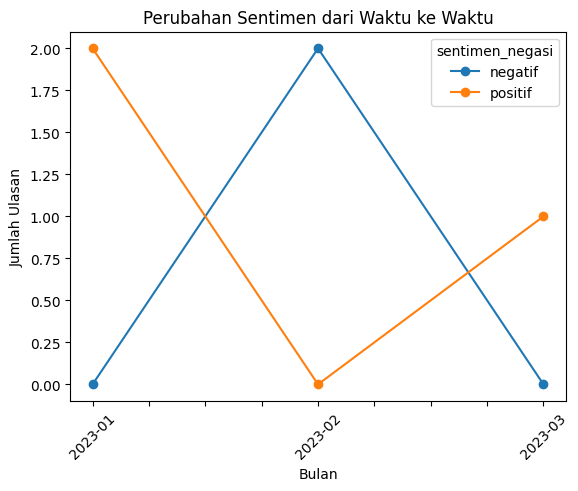

In [ ]:
sentimen_bulanan.plot(kind="line", marker="o")

plt.xlabel("Bulan")
plt.ylabel("Jumlah Ulasan")
plt.title("Perubahan Sentimen dari Waktu ke Waktu")
plt.xticks(rotation=45)
plt.show()

## Fine-tuning IndoBERT untuk Klasifikasi Sentimen

**IndoBERT** adalah model bahasa BERT (Bidirectional Encoder Representations from Transformers) yang telah dilatih secara khusus untuk bahasa Indonesia. Menggunakan model _pre-trained_ seperti IndoBERT dan melakukan _fine-tuning_ pada tugas spesifik (dalam hal ini, klasifikasi sentimen) dapat menghasilkan kinerja yang jauh lebih baik dibandingkan melatih model dari awal.

Proses _fine-tuning_ melibatkan langkah-langkah berikut:
1.  **Memuat Tokenizer dan Model:** Menggunakan `AutoTokenizer` dan `AutoModelForSequenceClassification` dari pustaka `transformers` untuk memuat model IndoBERT. `AutoConfig` digunakan untuk menyesuaikan jumlah label dan pemetaan label-ID sesuai dengan tugas klasifikasi sentimen kita (negatif, netral, positif).
2.  **Tokenisasi Data:** Mengubah teks mentah menjadi format numerik (token IDs, attention masks) yang dapat dipahami oleh model BERT menggunakan tokenizer yang sesuai.
3.  **Membuat Dataset Hugging Face:** Mengkonversi `pandas.DataFrame` menjadi objek `Dataset` dari pustaka `datasets`, yang merupakan format yang efisien untuk _fine-tuning_ model transformer.
4.  **Konfigurasi `TrainingArguments`:** Menentukan parameter pelatihan seperti jumlah _epoch_, ukuran _batch_, _learning rate_, dan direktori penyimpanan model.
5.  **Inisialisasi `Trainer`:** Menggunakan kelas `Trainer` dari `transformers` untuk mengabstraksi proses _fine-tuning_ dan evaluasi.
6.  **Pelatihan Model (`trainer.train()`):** Melakukan proses _fine-tuning_. Langkah ini memerlukan lingkungan dengan GPU untuk efisiensi komputasi.
7.  **Inferensi:** Setelah model dilatih, sebuah fungsi `prediksi_sentimen_bert` dibuat untuk memprediksi sentimen pada teks baru.

In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoConfig,
    TrainingArguments, Trainer
)
from datasets import Dataset
import torch
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

# ── Muat tokenizer dan model IndoBERT ──
MODEL_NAME = 'indobenchmark/indobert-base-p1'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Define custom id2label and label2id for 3 classes
id2label = {0: 'negatif', 1: 'netral', 2: 'positif'}
label2id = {'negatif': 0, 'netral': 1, 'positif': 2}

# Load the base configuration
config = AutoConfig.from_pretrained(MODEL_NAME)

# Update configuration attributes manually
config.num_labels = len(id2label)
config.id2label = id2label
config.label2id = label2id

# Load the model with the updated configuration
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)

# ── Tokenisasi dengan IndoBERT tokenizer ──
def tokenisasi_bert(contoh, max_length=128):
    return tokenizer(
        contoh['teks'],
        max_length  = max_length,
        truncation  = True,
        padding      = 'max_length',
        return_tensors = None,
    )

# Konversi DataFrame ke Dataset Hugging Face
# Create df_train and df_test from X_train, y_train, X_test, y_test
# Assuming X_train/X_test are the 'teks' and y_train/y_test are the 'labels'
df_train = pd.DataFrame({'teks': X_train, 'label': y_train})
df_test  = pd.DataFrame({'teks': X_test,  'label': y_test})

# Map string labels to numerical IDs
df_train['label'] = df_train['label'].map(label2id)
df_test['label'] = df_test['label'].map(label2id)

# Remove rows with NaN labels if 'netral' was not found in data and mapped to NaN
df_train.dropna(subset=['label'], inplace=True)
df_test.dropna(subset=['label'], inplace=True)

ds_train = Dataset.from_pandas(df_train[['teks', 'label']])
ds_test  = Dataset.from_pandas(df_test[['teks', 'label']])

ds_train = ds_train.map(tokenisasi_bert, batched=True)
ds_test  = ds_test.map(tokenisasi_bert,  batched=True)

# Set format for PyTorch
ds_train.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
ds_test.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# ── Konfigurasi fine-tuning ──
def hitung_metrik(eval_pred):
    logits, labels = eval_pred
    prediksi = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, prediksi),
        'f1_macro': f1_score(labels, prediksi, average='macro'),
    }

training_args = TrainingArguments(
    output_dir          = 'model/indobert-sentimen',
    num_train_epochs    = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_steps        = 200,
    weight_decay        = 0.01,
    # evaluation_strategy = 'epoch', # Removed due to TypeError
    # save_strategy       = 'epoch', # Removed due to TypeError
    # load_best_model_at_end = True, # Removed due to TypeError
    # metric_for_best_model  = 'f1_macro', # Removed due to TypeError
    learning_rate        = 2e-5,
    seed                = 42,
    report_to           = 'none',
)

trainer = Trainer(
    model           = model_bert,
    args            = training_args,
    train_dataset   = ds_train,
    eval_dataset    = ds_test,
    compute_metrics = hitung_metrik,
)

# Fine-tune (membutuhkan GPU — jalankan di Google Colab dengan GPU runtime)
# trainer.train()
# trainer.save_model('model/indobert-sentimen-final')

# ── Inferensi: prediksi sentimen teks baru ──
def prediksi_sentimen_bert(teks_list, model, tokenizer,
                            label_map={0:'negatif',1:'netral',2:'positif'}):
    inputs = tokenizer(teks_list, truncation=True, padding=True,
                       max_length=128, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**inputs)
    prediksi = torch.argmax(outputs.logits, dim=1).numpy()
    return [label_map[p] for p in prediksi]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
import joblib

# ════════════════════════════════════════════════════════
# LANGKAH 1: MUAT DAN EKSPLORASI DATA
# ════════════════════════════════════════════════════════
# Dataset: tweet berbahasa Indonesia dengan label sentimen
# Sumber: IndoNLU / Kaggle (tersedia di repositori buku)
url = 'https://raw.githubusercontent.com/wmaharani/prinsip-sains-data/main/data/tweet_sentimen_id.csv'

# Read the file as a single column first, then manually split into 'sentimen' and 'Tweet'
# This approach is robust against inconsistent separators in pd.read_csv
df_raw = pd.read_csv(url, header=None, names=['raw_line'])

# The first line is the actual header (e.g., "sentimen\tTweet"). We skip it.
df_data = df_raw.iloc[1:].copy()

# Now, split the 'raw_line' column into 'sentimen' and 'Tweet' using whitespace as the delimiter
df_data[['sentimen', 'Tweet']] = df_data['raw_line'].str.split(n=1, expand=True)

# Convert 'sentimen' to numeric type
df_data['sentimen'] = pd.to_numeric(df_data['sentimen'])

# Filter out invalid sentiment values (e.g., 2000), keeping only -1, 0, 1
df_data = df_data[df_data['sentimen'].isin([-1, 0, 1])].copy()

# Rename 'Tweet' column to 'teks' for consistency with NLP pipeline
df = df_data.rename(columns={'Tweet': 'teks'})

# Drop the temporary 'raw_line' column
df = df.drop(columns=['raw_line'])

print(f'Total data: {len(df):,} tweet')
print(f'Distribusi sentimen:\n{df["sentimen"].value_counts()}')

# ════════════════════════════════════════════════════════
# LANGKAH 2: PRA-PEMROSESAN (Pipeline Bab 7)
# ════════════════════════════════════════════════════════
# Gunakan kelas PipelineNLPIndonesia dari Bab 7
# from pipeline_nlp import PipelineNLPIndonesia # Removed this import

nlp = PipelineNLPIndonesia(
    gunakan_stemming=True,
    gunakan_stopword=True,
    gunakan_normalisasi=True,
)

print('Memproses teks...')
df['teks_bersih'] = nlp.proses_batch(df['teks'].astype(str).tolist())
print('Selesai.')

# ════════════════════════════════════════════════════════
# LANGKAH 3: SPLIT DAN BANGUN MODEL
# ════════════════════════════════════════════════════════
X = df['teks_bersih']
y = df['sentimen']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=8000, ngram_range=(1,2),
        sublinear_tf=True, min_df=3, max_df=0.9,
    )),
    ('clf', LinearSVC(C=0.8, max_iter=2000, random_state=42,
                       class_weight='balanced')),
])

# Cross-validation pada data latih
cv_scores = cross_val_score(pipeline, X_train, y_train,
                             cv=5, scoring='f1_macro')
print(f'CV F1-macro: {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}')

# Fit pada seluruh data latih
pipeline.fit(X_train, y_train)

# ════════════════════════════════════════════════════════
# LANGKAH 4: EVALUASI
# ════════════════════════════════════════════════════════
y_pred = pipeline.predict(X_test)
print('\n=== LAPORAN EVALUASI AKHIR ===')
print(classification_report(y_test, y_pred,
      target_names=['negatif', 'netral', 'positif']))

# ════════════════════════════════════════════════════════
# LANGKAH 5: ANALISIS KESALAHAN
# ════════════════════════════════════════════════════════
df_test_eval = X_test.to_frame()
df_test_eval['label_asli']   = y_test.values
df_test_eval['label_prediksi'] = y_pred
df_test_eval['benar'] = df_test_eval['label_asli'] == df_test_eval['label_prediksi']

# Tampilkan contoh kesalahan prediksi
print('\nContoh kesalahan prediksi (positif diprediksi negatif):')
salah = df_test_eval[
    (df_test_eval['label_asli']=='positif') &
    (df_test_eval['label_prediksi']=='negatif')
]
print(salah.head(3)[['teks_bersih', 'label_asli', 'label_prediksi']].to_string())

# ════════════════════════════════════════════════════════
# LANGKAH 6: SIMPAN MODEL
# ════════════════════════════════════════════════════════
joblib.dump(pipeline, 'model/sentimen_svm_tfidf_v1.pkl')
print('\nModel tersimpan: model/sentimen_svm_tfidf_v1.pkl')

# ── Inferensi: prediksi teks baru ──
def prediksi_sentimen(teks_list, pipeline, nlp_pipeline):
    teks_bersih = nlp_pipeline.proses_batch(teks_list, verbose=False)
    prediksi    = pipeline.predict(teks_bersih)
    return list(zip(teks_list, prediksi))

# Demo
teks_baru = [
    'Produk keren banget, recommended! Pengiriman super cepat.',
    'Kecewa banget, barang rusak dan seller tidak mau refund.',
    'Biasa aja, standar sama kayak yang lain.',
]
for teks, sentimen in prediksi_sentimen(teks_baru, pipeline, nlp):
    print(f'{sentimen:10}: {teks[:50]}')

Total data: 10,805 tweet
Distribusi sentimen:
sentimen
 0    5326
-1    2887
 1    2592
Name: count, dtype: int64
Memproses teks...
Processed 1000/10805 texts.
Processed 2000/10805 texts.
Processed 3000/10805 texts.
Processed 4000/10805 texts.
Processed 5000/10805 texts.
Processed 6000/10805 texts.
Processed 7000/10805 texts.
Processed 8000/10805 texts.
Processed 9000/10805 texts.
Processed 10000/10805 texts.
Selesai.
CV F1-macro: 0.5513 ± 0.0111

=== LAPORAN EVALUASI AKHIR ===
              precision    recall  f1-score   support

     negatif       0.54      0.54      0.54       578
      netral       0.67      0.66      0.67      1065
     positif       0.55      0.56      0.55       518

    accuracy                           0.61      2161
   macro avg       0.59      0.59      0.59      2161
weighted avg       0.61      0.61      0.61      2161


Contoh kesalahan prediksi (positif diprediksi negatif):
Empty DataFrame
Columns: [teks_bersih, label_asli, label_prediksi]
Index: []

M

## Pipeline Analisis Sentimen Komprehensif

Bagian ini mengintegrasikan berbagai teknik NLP yang telah kita pelajari untuk membangun sebuah _pipeline_ analisis sentimen _end-to-end_. Tujuannya adalah untuk mengklasifikasikan sentimen (negatif, netral, positif) dari tweet berbahasa Indonesia menggunakan model _machine learning_ klasik (SVM dengan fitur TF-IDF).

_Pipeline_ ini terdiri dari beberapa langkah kunci:

1.  **Muat dan Eksplorasi Data:** Memuat dataset tweet dari sumber eksternal dan melakukan eksplorasi awal untuk memahami struktur data dan distribusi sentimen.
2.  **Pra-pemrosesan Teks:** Mengaplikasikan serangkaian teknik pra-pemrosesan menggunakan kelas `PipelineNLPIndonesia` yang telah didefinisikan sebelumnya. Ini meliputi _lowercasing_, penghapusan karakter non-alfanumerik, _tokenisasi_, penghapusan _stopword_, dan _stemming_. Tujuannya adalah untuk membersihkan teks dan mengubahnya menjadi format yang lebih terstruktur untuk analisis.
3.  **Split Data dan Bangun Model:**
    *   Memisahkan data menjadi _training set_ dan _test set_ menggunakan `train_test_split` dengan stratifikasi untuk memastikan distribusi kelas yang seimbang.
    *   Membangun _pipeline_ model yang menggabungkan `TfidfVectorizer` (untuk mengubah teks bersih menjadi representasi numerik) dan `LinearSVC` (sebagai model klasifikasi).
    *   Melakukan _cross-validation_ pada _training set_ untuk mendapatkan estimasi kinerja model yang lebih _robust_.
    *   Melatih model pada seluruh _training set_.
4.  **Evaluasi Model:** Mengevaluasi kinerja model yang telah dilatih pada _test set_ menggunakan metrik seperti _precision_, _recall_, dan _f1-score_ yang diringkas dalam _classification report_.
5.  **Analisis Kesalahan:** Menginspeksi contoh-contoh kesalahan prediksi untuk mendapatkan wawasan tentang area di mana model masih kesulitan.
6.  **Simpan Model dan Inferensi:** Menyimpan model yang telah dilatih untuk penggunaan di masa mendatang dan mendemonstrasikan bagaimana model dapat digunakan untuk memprediksi sentimen pada teks-teks baru.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Download NLTK stopwords if not already downloaded
try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

class PipelineNLPIndonesia:
    def __init__(self, gunakan_stemming=True, gunakan_stopword=True, gunakan_normalisasi=True):
        self.gunakan_stemming = gunakan_stemming
        self.gunakan_stopword = gunakan_stopword
        self.gunakan_normalisasi = gunakan_normalisasi

        if self.gunakan_stemming:
            self.stemmer = StemmerFactory().create_stemmer()
        if self.gunakan_stopword:
            self.list_stopwords = set(stopwords.words('indonesian'))

    def proses_teks(self, teks):
        teks = teks.lower() # Lowercasing

        if self.gunakan_normalisasi:
            # Simple normalization: remove non-alphanumeric, extra spaces
            teks = re.sub(r'[^a-zA-Z\s]', '', teks)
            teks = re.sub(r'\s+', ' ', teks).strip()

        tokens = teks.split()

        if self.gunakan_stopword:
            tokens = [token for token in tokens if token not in self.list_stopwords]

        if self.gunakan_stemming:
            tokens = [self.stemmer.stem(token) for token in tokens]

        return ' '.join(tokens)

    def proses_batch(self, teks_list, verbose=True):
        processed_texts = []
        for i, teks in enumerate(teks_list):
            processed_texts.append(self.proses_teks(teks))
            if verbose and (i + 1) % 1000 == 0:
                print(f'Processed {i+1}/{len(teks_list)} texts.')
        return processed_texts